In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import joblib
import time
import os

print(f"TensorFlow version: {tf.__version__}")
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

TensorFlow version: 2.21.0


In [5]:
pip install tensorflow

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.45.1 requires protobuf<7,>=3.20, but you have protobuf 7.35.0 which is incompatible.



  Using cached tensorflow-2.21.0-cp313-cp313-win_amd64.whl.metadata (4.5 kB)
  Using cached absl_py-2.4.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached protobuf-7.35.0-cp310-abi3-win_amd64.whl.metadata (595 bytes)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached grpcio-1.81.0-cp313-cp313-win_amd64.whl.metadata (3.8 kB)
  Using cached keras-3.14.1-py3-none-any.whl.metadata (6.3 kB)
  Using cached ml_dtypes-0.5.4-cp313-cp313-win_amd64.whl.metadata (9.2 kB)
  Using cached namex-0.1.0-py3-none-any.whl.metadata (322 bytes)
  Using cached op

In [8]:
# Load scaled features and targets from Day 4
X_train = pd.read_csv('data/processed/X_train_scaled.csv')
X_val = pd.read_csv('data/processed/X_val_scaled.csv')
y_train = pd.read_csv('data/processed/y_train.csv').squeeze()
y_val = pd.read_csv('data/processed/y_val.csv').squeeze()

# Load val data with engine info (needed for per-engine plots)
val_with_info = pd.read_csv('data/processed/val_with_rul.csv')

print(f"X_train shape: {X_train.shape}")
print(f"X_val shape:   {X_val.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_val shape:   {y_val.shape}")

X_train shape: (16340, 75)
X_val shape:   (4291, 75)
y_train shape: (16340,)
y_val shape:   (4291,)


## Why We Need to Reshape Data for LSTM

XGBoost saw data as flat rows: (samples, features)
- Each row = one cycle of one engine
- No temporal context between rows

LSTM needs data as sequences: (samples, timesteps, features)
- Each "sample" = a SEQUENCE of consecutive cycles
- timesteps = how many cycles per sequence (we'll use 30)
- features = sensor readings at each cycle

We use a SLIDING WINDOW approach:
- For engine with 200 cycles, we create many overlapping windows
- Window 1: cycles 1-30 → predict RUL at cycle 30
- Window 2: cycles 2-31 → predict RUL at cycle 31
- Window 3: cycles 3-32 → predict RUL at cycle 32
- etc.

In [10]:
def create_sequences(X, y, engine_ids, sequence_length=30):
    """
    Creates sliding window sequences for LSTM input.
    
    Args:
        X: Feature matrix (scaled)
        y: Target values (RUL)
        engine_ids: Engine ID for each row (to avoid crossing engines)
        sequence_length: Number of cycles per sequence (window size)
    
    Returns:
        X_seq: 3D array (samples, timesteps, features)
        y_seq: 1D array (samples,)
    """
    X_seq = []
    y_seq = []
    
    unique_engines = np.unique(engine_ids)
    
    for engine in unique_engines:
        # Get all rows for this engine
        engine_mask = engine_ids == engine
        X_engine = X[engine_mask]
        y_engine = y[engine_mask]
        
        # Create sliding windows for this engine
        num_cycles = len(X_engine)
        
        for i in range(sequence_length, num_cycles + 1):
            # Window: cycles i-sequence_length to i
            X_seq.append(X_engine[i - sequence_length:i])
            # Target: RUL at end of window (cycle i)
            y_seq.append(y_engine[i - 1])
    
    return np.array(X_seq), np.array(y_seq)



In [12]:
SEQUENCE_LENGTH = 30  # 30 cycles per sequence

# Get engine IDs for grouping
train_engine_ids = pd.read_csv('data/processed/train_with_rul.csv')['unit_number'].values
val_engine_ids = val_with_info['unit_number'].values

# Create sequences

X_train_seq, y_train_seq = create_sequences(
    X_train.values, 
    y_train.values, 
    train_engine_ids,
    sequence_length=SEQUENCE_LENGTH
)


X_val_seq, y_val_seq = create_sequences(
    X_val.values,
    y_val.values,
    val_engine_ids,
    sequence_length=SEQUENCE_LENGTH
)

print(f"\nTraining sequences shape:   {X_train_seq.shape}")
print(f"Training targets shape:     {y_train_seq.shape}")
print(f"Validation sequences shape: {X_val_seq.shape}")
print(f"Validation targets shape:   {y_val_seq.shape}")


Training sequences shape:   (14020, 30, 75)
Training targets shape:     (14020,)
Validation sequences shape: (3711, 30, 75)
Validation targets shape:   (3711,)


In [15]:
# Quick sanity check
print(f"One training sequence shape: {X_train_seq[0].shape}")

print(f"\nMin RUL: {y_train_seq.min():.1f}")
print(f"Max RUL: {y_train_seq.max():.1f}")
print(f"Mean RUL: {y_train_seq.mean():.1f}")

One training sequence shape: (30, 75)

Min RUL: 0.0
Max RUL: 125.0
Mean RUL: 80.1


In [19]:
from keras.layers import Input, LSTM, Dense, Dropout
from keras.models import Sequential

model = Sequential([
    Input(shape=(n_timesteps, n_features)),

    LSTM(
        units=64,
        return_sequences=True
    ),
    Dropout(0.2),

    LSTM(
        units=32,
        return_sequences=False
    ),
    Dropout(0.2),

    Dense(1)
])
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 30, 64)         │        35,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 48,289 (188.63 KB)

 Trainable params: 48,289 (188.63 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
model.compile(
    optimizer='adam',         # Adam optimizer — standard default
    loss='mse',               # Mean Squared Error — good for regression
    metrics=['mae']           # Also track MAE during training
)


print(f"\nTotal trainable parameters: {model.count_params():,}")



Total trainable parameters: 48,289


In [21]:
# Callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',      # Watch validation loss
    patience=10,             # Stop if no improvement for 10 epochs
    restore_best_weights=True  # Revert to best weights when stopping
)

model_checkpoint = ModelCheckpoint(
    filepath='data/processed/lstm_best_model.keras',
    monitor='val_loss',
    save_best_only=True,     # Only save when val_loss improves
    verbose=1
)

# Train
print("Training LSTM... (this will take a few minutes)")
start_time = time.time()

history = model.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=50,               # Max 50 epochs
    batch_size=64,           # 64 sequences per gradient update
    callbacks=[early_stopping, model_checkpoint],
    verbose=1                # Print progress each epoch
)

training_time = time.time() - start_time
print(f"\n Training complete in {training_time:.1f} seconds")
print(f"Stopped at epoch: {len(history.history['loss'])}")

Training LSTM... (this will take a few minutes)
Epoch 1/50
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 7249.2758 - mae: 74.5891
Epoch 1: val_loss improved from None to 6494.56934, saving model to data/processed/lstm_best_model.keras

Epoch 1: finished saving model to data/processed/lstm_best_model.keras
220/220 ━━━━━━━━━━━━━━━━━━━━ 13s 35ms/step - loss: 6807.7495 - mae: 71.7140 - val_loss: 6494.5693 - val_mae: 69.9534
Epoch 2/50
219/220 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 5937.2344 - mae: 65.9477
Epoch 2: val_loss improved from 6494.56934 to 5604.65234, saving model to data/processed/lstm_best_model.keras

Epoch 2: finished saving model to data/processed/lstm_best_model.keras
220/220 ━━━━━━━━━━━━━━━━━━━━ 11s 37ms/step - loss: 5720.6191 - mae: 64.6260 - val_loss: 5604.6523 - val_mae: 63.9841
Epoch 3/50
219/220 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 5088.2064 - mae: 60.0271
Epoch 3: val_loss improved from 5604.65234 to 4844.44385, saving model to data/processed/lstm_best_m

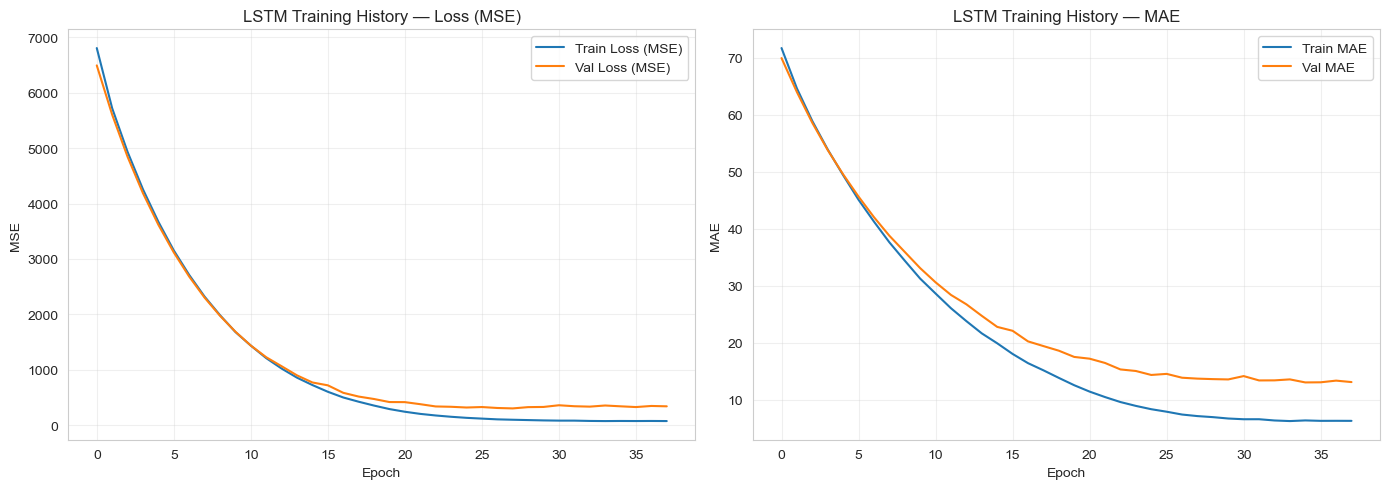

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss (MSE)
axes[0].plot(history.history['loss'], label='Train Loss (MSE)')
axes[0].plot(history.history['val_loss'], label='Val Loss (MSE)')
axes[0].set_title('LSTM Training History — Loss (MSE)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# MAE
axes[1].plot(history.history['mae'], label='Train MAE')
axes[1].plot(history.history['val_mae'], label='Val MAE')
axes[1].set_title('LSTM Training History — MAE')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plots/lstm_training_history.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
# Load best saved model
from tensorflow.keras.models import load_model
best_model = load_model('data/processed/lstm_best_model.keras')

# Predict
y_val_pred_lstm = best_model.predict(X_val_seq).flatten()

# Metrics
rmse_lstm = np.sqrt(mean_squared_error(y_val_seq, y_val_pred_lstm))
mae_lstm = mean_absolute_error(y_val_seq, y_val_pred_lstm)
r2_lstm = r2_score(y_val_seq, y_val_pred_lstm)

print("=" * 50)
print("LSTM Model — Validation Results")
print("=" * 50)
print(f"RMSE: {rmse_lstm:.2f} cycles")
print(f"MAE:  {mae_lstm:.2f} cycles")
print(f"R²:   {r2_lstm:.4f}")
print("=" * 50)

# Compare with XGBoost
print("\nComparison:")
print(f"XGBoost RMSE: 20.03  →  LSTM RMSE: {rmse_lstm:.2f}")
print(f"XGBoost R²:   0.7673 →  LSTM R²:   {r2_lstm:.4f}")

improvement = ((20.03 - rmse_lstm) / 20.03) * 100
print(f"\nRMSE improvement: {improvement:.1f}%")

116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step   
LSTM Model — Validation Results
RMSE: 17.40 cycles
MAE:  13.72 cycles
R²:   0.8270

Comparison:
XGBoost RMSE: 20.03  →  LSTM RMSE: 17.40
XGBoost R²:   0.7673 →  LSTM R²:   0.8270

RMSE improvement: 13.1%


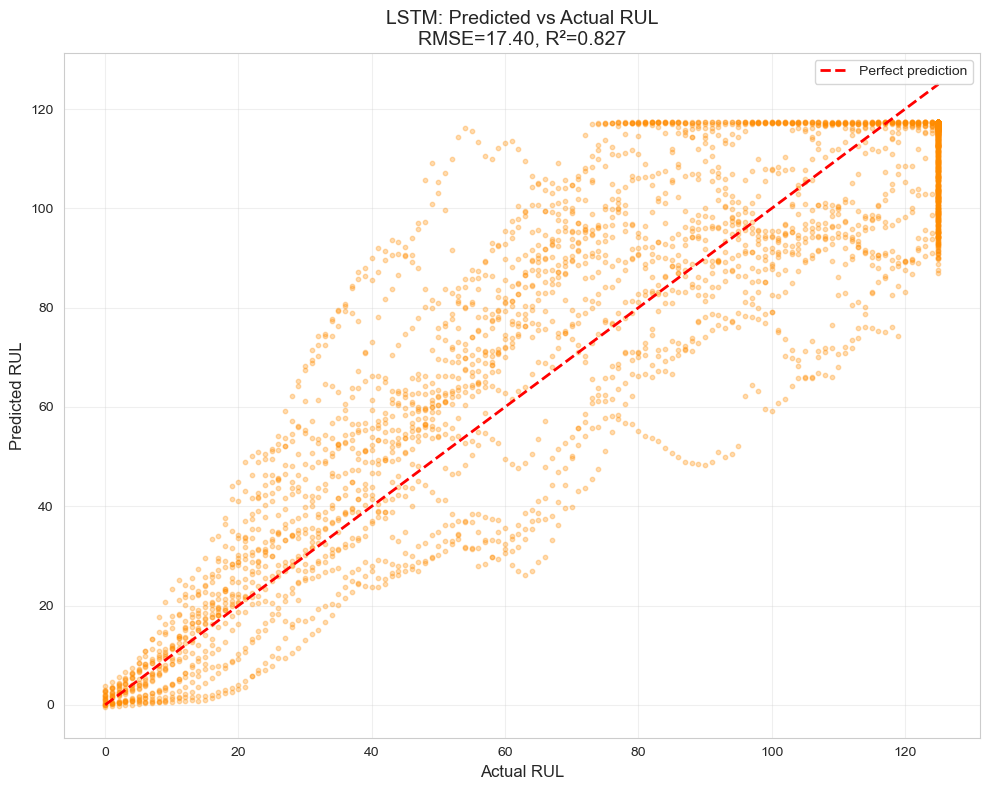

In [24]:
fig, ax = plt.subplots(figsize=(10, 8))

ax.scatter(y_val_seq, y_val_pred_lstm, alpha=0.3, s=10, color='darkorange')
max_val = max(y_val_seq.max(), y_val_pred_lstm.max())
ax.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Perfect prediction')
ax.set_xlabel('Actual RUL', fontsize=12)
ax.set_ylabel('Predicted RUL', fontsize=12)
ax.set_title(f'LSTM: Predicted vs Actual RUL\nRMSE={rmse_lstm:.2f}, R²={r2_lstm:.3f}', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plots/lstm_pred_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

## Day 13 Summary — LSTM Model Complete

### Architecture
- Input: (30 timesteps × 75 features)
- Layer 1: LSTM(64, return_sequences=True) + Dropout(0.2)
- Layer 2: LSTM(32, return_sequences=False) + Dropout(0.2)
- Output: Dense(1) — predicted RUL

### Results
| Model | RMSE | MAE | R² |
|---|---|---|---|
| XGBoost (baseline) | 20.16 | 14.18 | 0.7642 |
| XGBoost (tuned) | 20.03 | 14.00 | 0.7673 |
| LSTM | 17.40 |13.72 | 0.8270 |

### Key Decisions
- Sequence length = 30 cycles (enough context, not too much memory)
- 2 LSTM layers (first extracts patterns, second combines them)
- EarlyStopping (patience=10) prevents overfitting
- Adam optimizer (default learning rate)
